In [1]:
# Install required libraries
!pip install -q kagglehub librosa tensorflow scikit-learn matplotlib tqdm

# Download ICBHI Dataset from Kaggle
import kagglehub
import os

print("📥 Downloading ICBHI 2017 Dataset...")
dataset_path = kagglehub.dataset_download("nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database")
print(f"✅ Downloaded to: {dataset_path}")

# Explore the dataset structure
print("\n📁 Dataset contents:")
for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        files_inside = os.listdir(full_path)
        print(f"  📂 {item}/ → {len(files_inside)} files")
        # Show sample files
        for f in files_inside[:5]:
            print(f"      {f}")
    else:
        print(f"  📄 {item}")

# Auto-detect the folder containing .wav files
DATASET_PATH = dataset_path

# Check if wav files are in a subfolder
wav_count = len([f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')])
if wav_count == 0:
    # Look in subfolders
    for item in os.listdir(dataset_path):
        sub = os.path.join(dataset_path, item)
        if os.path.isdir(sub):
            wav_count_sub = len([f for f in os.listdir(sub) if f.endswith('.wav')])
            if wav_count_sub > 0:
                DATASET_PATH = sub
                wav_count = wav_count_sub
                print(f"\n🎯 Found WAV files in: {sub}")
                break

print(f"\n📊 WAV files found: {wav_count}")
txt_count = len([f for f in os.listdir(DATASET_PATH) if f.endswith('.txt')])
print(f"📊 TXT annotation files found: {txt_count}")
print(f"\n✅ DATASET_PATH = '{DATASET_PATH}'")

📥 Downloading ICBHI 2017 Dataset...


100%|██████████| 1.84G/1.84G [01:25<00:00, 23.1MB/s]

Extracting files...


✅ Downloaded to: /root/.cache/kagglehub/datasets/nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database/versions/1

📁 Dataset contents:
  📂 ICBHI_final_database/ → 1843 files
      147_2b4_Ar_mc_AKGC417L.txt
      156_2b3_Al_mc_AKGC417L.txt
      130_2b2_Pr_mc_AKGC417L.txt
      186_2b4_Ar_mc_AKGC417L.txt
      222_1b1_Ar_sc_Meditron.txt

🎯 Found WAV files in: /root/.cache/kagglehub/datasets/nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database/versions/1/ICBHI_final_database

📊 WAV files found: 920
📊 TXT annotation files found: 922

✅ DATASET_PATH = '/root/.cache/kagglehub/datasets/nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database/versions/1/ICBHI_final_database'


In [2]:
import os
import numpy as np
import librosa
import librosa.display
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import warnings
warnings.filterwarnings('ignore')

# Check GPU
print(f"🔧 TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
else:
    print("⚠️ No GPU! Go to Runtime → Change runtime type → T4 GPU")

# ==================== SETTINGS ====================
# Audio Processing
SAMPLE_RATE = 16000       # Hz
DURATION = 5.0            # seconds per clip
N_MELS = 128              # Mel bands
HOP_LENGTH = 512
N_FFT = 2048

# Training
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# Paths
OUTPUT_PATH = "/content/processed_data"
MODEL_PATH = "/content/saved_model"

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("\n✅ Settings loaded!")
print(f"   Sample Rate: {SAMPLE_RATE} Hz")
print(f"   Clip Duration: {DURATION}s")
print(f"   Mel Bands: {N_MELS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max Epochs: {EPOCHS}")

🔧 TensorFlow version: 2.19.0
✅ GPU detected: /physical_device:GPU:0

✅ Settings loaded!
   Sample Rate: 16000 Hz
   Clip Duration: 5.0s
   Mel Bands: 128
   Batch Size: 32
   Max Epochs: 100


In [3]:
def parse_annotation(txt_path):
    """
    قراءة ملف الـ annotation
    كل سطر: start_time  end_time  crackle(0/1)  wheeze(0/1)
    """
    cycles = []
    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 4:
                try:
                    cycles.append({
                        'start': float(parts[0]),
                        'end': float(parts[1]),
                        'crackle': int(parts[2]),
                        'wheeze': int(parts[3])
                    })
                except ValueError:
                    continue
    return cycles


def extract_mel_spectrogram(audio, sr=SAMPLE_RATE):
    """
    تحويل الصوت إلى Mel Spectrogram
    """
    target_length = int(DURATION * sr)

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
    else:
        audio = audio[:target_length]

    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr,
        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalize to [0, 1]
    mel_min = mel_spec_db.min()
    mel_max = mel_spec_db.max()
    if mel_max - mel_min > 0:
        mel_spec_db = (mel_spec_db - mel_min) / (mel_max - mel_min)
    else:
        mel_spec_db = np.zeros_like(mel_spec_db)

    return mel_spec_db


# ==================== PROCESS ALL FILES ====================
spectrograms = []
labels = []
metadata = []  # لحفظ معلومات إضافية

wav_files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')])
print(f"📁 Found {len(wav_files)} WAV files")
print("🔄 Processing audio files...\n")

skipped = 0
errors = 0

for wav_file in tqdm(wav_files, desc="Processing files"):
    base_name = wav_file.replace('.wav', '')
    txt_path = os.path.join(DATASET_PATH, base_name + '.txt')
    wav_path = os.path.join(DATASET_PATH, wav_file)

    if not os.path.exists(txt_path):
        skipped += 1
        continue

    # Load audio
    try:
        audio, sr = librosa.load(wav_path, sr=SAMPLE_RATE)
    except Exception as e:
        errors += 1
        continue

    # Parse annotations
    cycles = parse_annotation(txt_path)

    for cycle in cycles:
        start_sample = int(cycle['start'] * sr)
        end_sample = int(cycle['end'] * sr)
        segment = audio[start_sample:end_sample]

        # Skip very short segments
        if len(segment) < int(0.3 * sr):
            continue

        try:
            mel_spec = extract_mel_spectrogram(segment, sr)
            spectrograms.append(mel_spec)

            # Binary: 0 = Normal, 1 = Wheeze (with or without crackle)
            label = 1 if cycle['wheeze'] == 1 else 0
            labels.append(label)

            metadata.append({
                'file': wav_file,
                'start': cycle['start'],
                'end': cycle['end'],
                'crackle': cycle['crackle'],
                'wheeze': cycle['wheeze']
            })
        except Exception:
            errors += 1
            continue

spectrograms = np.array(spectrograms)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"✅ Processing Complete!")
print(f"{'='*50}")
print(f"📊 Total respiratory cycles: {len(labels)}")
print(f"   🟢 Normal:  {np.sum(labels == 0)} ({np.sum(labels == 0)/len(labels)*100:.1f}%)")
print(f"   🔴 Wheeze:  {np.sum(labels == 1)} ({np.sum(labels == 1)/len(labels)*100:.1f}%)")
print(f"   ⚠️ Skipped: {skipped}, Errors: {errors}")
print(f"📐 Spectrogram shape: {spectrograms[0].shape}")

📁 Found 920 WAV files
🔄 Processing audio files...



Processing files: 100%|██████████| 920/920 [01:46<00:00,  8.66it/s]



✅ Processing Complete!
📊 Total respiratory cycles: 6892
   🟢 Normal:  5501 (79.8%)
   🔴 Wheeze:  1391 (20.2%)
   ⚠️ Skipped: 0, Errors: 0
📐 Spectrogram shape: (128, 157)


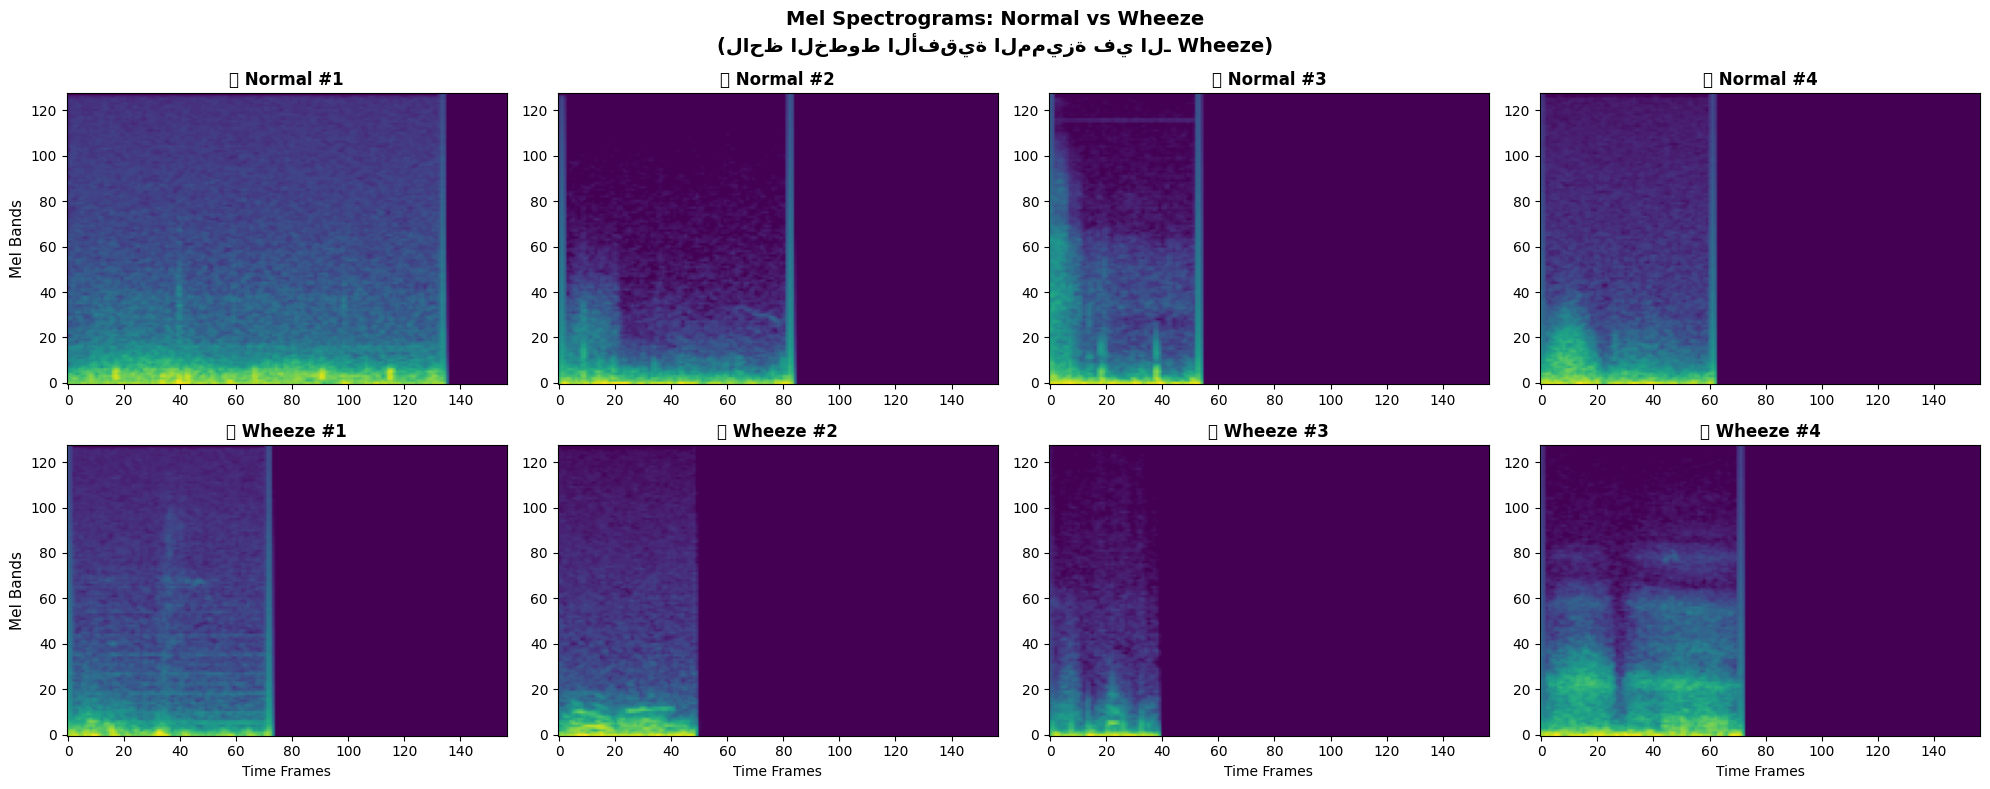

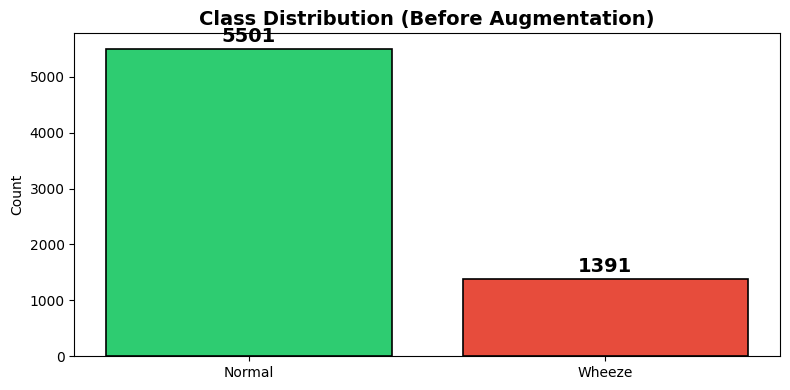

⚖️ Imbalance ratio: 1:4.0 (Wheeze:Normal)


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Normal samples
normal_indices = np.where(labels == 0)[0]
np.random.seed(42)
selected_normal = np.random.choice(normal_indices, 4, replace=False)

for i, idx in enumerate(selected_normal):
    im = axes[0, i].imshow(spectrograms[idx], aspect='auto', origin='lower', cmap='viridis')
    axes[0, i].set_title(f'🟢 Normal #{i+1}', fontsize=12, fontweight='bold')
    if i == 0:
        axes[0, i].set_ylabel('Mel Bands', fontsize=11)

# Wheeze samples
wheeze_indices = np.where(labels == 1)[0]
selected_wheeze = np.random.choice(wheeze_indices, 4, replace=False)

for i, idx in enumerate(selected_wheeze):
    im = axes[1, i].imshow(spectrograms[idx], aspect='auto', origin='lower', cmap='viridis')
    axes[1, i].set_title(f'🔴 Wheeze #{i+1}', fontsize=12, fontweight='bold')
    if i == 0:
        axes[1, i].set_ylabel('Mel Bands', fontsize=11)
    axes[1, i].set_xlabel('Time Frames', fontsize=10)

plt.suptitle('Mel Spectrograms: Normal vs Wheeze\n(لاحظ الخطوط الأفقية المميزة في الـ Wheeze)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
classes, counts = np.unique(labels, return_counts=True)
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Normal', 'Wheeze'], counts, color=colors, edgecolor='black', linewidth=1.2)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.set_title('Class Distribution (Before Augmentation)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"⚖️ Imbalance ratio: 1:{np.sum(labels==0)/max(np.sum(labels==1),1):.1f} (Wheeze:Normal)")

📊 Before Augmentation:
   Normal: 5501, Wheeze: 1391

🔄 Creating 4110 augmented wheeze samples...


Augmenting wheeze: 100%|██████████| 4110/4110 [00:01<00:00, 2187.23it/s]


🔄 Creating 1100 augmented normal samples...


Augmenting normal: 100%|██████████| 1100/1100 [00:00<00:00, 2006.65it/s]



✅ After Augmentation:
   Normal: 6601
   Wheeze: 5501
   Total:  12102
   Shape:  (12102, 128, 157, 1)


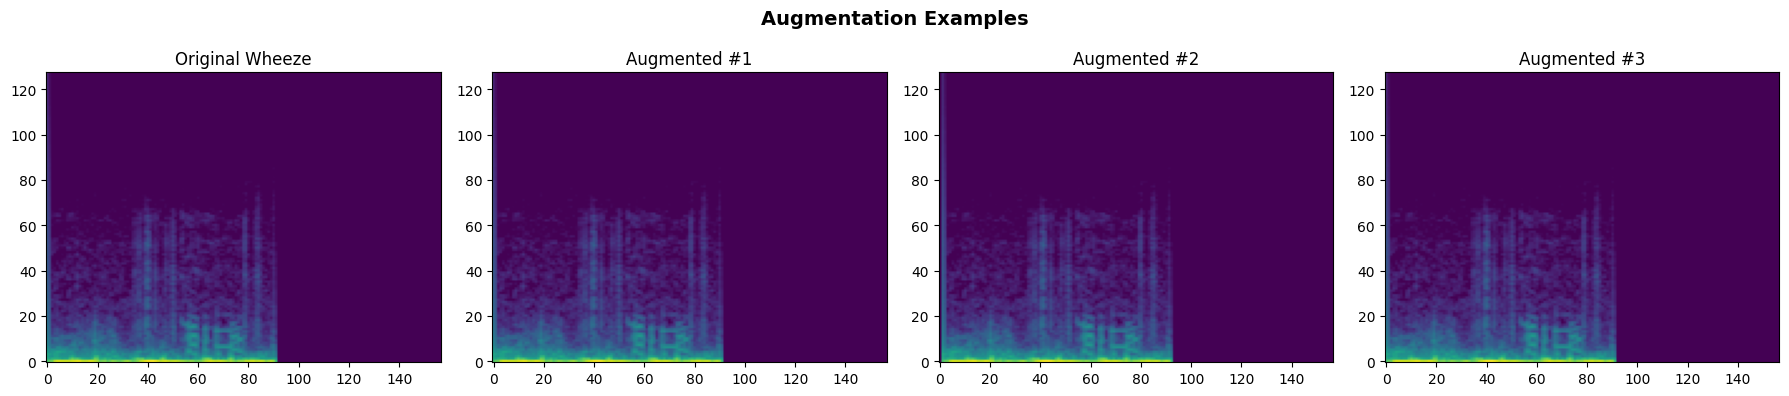

In [5]:
def time_shift(spec, shift_max=20):
    """إزاحة زمنية"""
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(spec, shift, axis=1)


def freq_mask(spec, max_mask=15):
    """إخفاء ترددات عشوائية"""
    spec = spec.copy()
    num_mels = spec.shape[0]
    mask_size = np.random.randint(1, max_mask)
    start = np.random.randint(0, num_mels - mask_size)
    spec[start:start + mask_size, :] = 0
    return spec


def time_mask(spec, max_mask=20):
    """إخفاء فترات زمنية"""
    spec = spec.copy()
    num_frames = spec.shape[1]
    mask_size = np.random.randint(1, min(max_mask, num_frames - 1))
    start = np.random.randint(0, num_frames - mask_size)
    spec[:, start:start + mask_size] = 0
    return spec


def add_noise(spec, noise_factor=0.05):
    """إضافة ضوضاء"""
    noise = np.random.randn(*spec.shape) * noise_factor
    return np.clip(spec + noise, 0, 1)


def augment_sample(spec):
    """تطبيق augmentations عشوائية"""
    augmented = spec.copy()
    if np.random.random() > 0.5:
        augmented = time_shift(augmented)
    if np.random.random() > 0.5:
        augmented = freq_mask(augmented)
    if np.random.random() > 0.5:
        augmented = time_mask(augmented)
    if np.random.random() > 0.5:
        augmented = add_noise(augmented)
    return augmented


# ==================== BALANCE CLASSES ====================
normal_specs = spectrograms[labels == 0]
wheeze_specs = spectrograms[labels == 1]

normal_count = len(normal_specs)
wheeze_count = len(wheeze_specs)

print(f"📊 Before Augmentation:")
print(f"   Normal: {normal_count}, Wheeze: {wheeze_count}")

# Augment wheeze (minority) to match normal
samples_needed = normal_count - wheeze_count
print(f"\n🔄 Creating {samples_needed} augmented wheeze samples...")

augmented_wheeze = []
for i in tqdm(range(samples_needed), desc="Augmenting wheeze"):
    idx = np.random.randint(0, wheeze_count)
    augmented_wheeze.append(augment_sample(wheeze_specs[idx]))
augmented_wheeze = np.array(augmented_wheeze)

# Also augment some normal for variety
aug_normal_count = int(normal_count * 0.2)
print(f"🔄 Creating {aug_normal_count} augmented normal samples...")

augmented_normal = []
for i in tqdm(range(aug_normal_count), desc="Augmenting normal"):
    idx = np.random.randint(0, normal_count)
    augmented_normal.append(augment_sample(normal_specs[idx]))
augmented_normal = np.array(augmented_normal)

# Combine
X = np.concatenate([normal_specs, augmented_normal, wheeze_specs, augmented_wheeze])
y = np.concatenate([
    np.zeros(len(normal_specs) + len(augmented_normal)),
    np.ones(len(wheeze_specs) + len(augmented_wheeze))
])

# Shuffle
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

# Add channel dimension
X = X[..., np.newaxis]  # (samples, 128, width, 1)

print(f"\n{'='*50}")
print(f"✅ After Augmentation:")
print(f"   Normal: {int(np.sum(y == 0))}")
print(f"   Wheeze: {int(np.sum(y == 1))}")
print(f"   Total:  {len(y)}")
print(f"   Shape:  {X.shape}")
print(f"{'='*50}")

# Visualize augmented samples
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(wheeze_specs[0], aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original Wheeze')
for i in range(3):
    aug = augment_sample(wheeze_specs[0])
    axes[i+1].imshow(aug, aspect='auto', origin='lower', cmap='viridis')
    axes[i+1].set_title(f'Augmented #{i+1}')
plt.suptitle('Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ⚡ اختر هنا:
USE_TRANSFER_LEARNING = False   # True = MobileNetV2, False = Custom CNN


def build_custom_cnn(input_shape):
    """
    Custom CNN مصمم خصيصاً لـ Mel Spectrograms
    4 Convolutional blocks + Classifier
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),

        # Classifier
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


def build_mobilenet(input_shape):
    """
    Transfer Learning with MobileNetV2
    Pretrained on ImageNet → Fine-tuned for respiratory sounds
    """
    base_model = keras.applications.MobileNetV2(
        input_shape=(input_shape[0], input_shape[1], 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze initially

    model = models.Sequential([
        # Convert 1 channel to 3 channels
        layers.Conv2D(3, (1, 1), padding='same', input_shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


# Build
input_shape = X.shape[1:]  # (128, width, 1)

if USE_TRANSFER_LEARNING:
    model = build_mobilenet(input_shape)
    print("🏗️ Model: MobileNetV2 (Transfer Learning)")
else:
    model = build_custom_cnn(input_shape)
    print("🏗️ Model: Custom CNN")

print(f"📐 Input shape: {input_shape}")
print(f"📊 Total parameters: {model.count_params():,}")
print()
model.summary()

🏗️ Model: Custom CNN
📐 Input shape: (128, 157, 1)
📊 Total parameters: 422,785



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 157, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 39, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 19, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 19, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 19, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# ==================== SPLIT DATA ====================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"📊 Data Split:")
print(f"   Train: {len(y_train):,} (Normal: {int(np.sum(y_train==0)):,}, Wheeze: {int(np.sum(y_train==1)):,})")
print(f"   Val:   {len(y_val):,} (Normal: {int(np.sum(y_val==0)):,}, Wheeze: {int(np.sum(y_val==1)):,})")
print(f"   Test:  {len(y_test):,} (Normal: {int(np.sum(y_test==0)):,}, Wheeze: {int(np.sum(y_test==1)):,})")

# ==================== CLASS WEIGHTS ====================
n_normal = int(np.sum(y_train == 0))
n_wheeze = int(np.sum(y_train == 1))
total = n_normal + n_wheeze

class_weight = {
    0: total / (2 * n_normal),
    1: total / (2 * n_wheeze) * 1.2  # 20% extra weight for wheeze
}
print(f"\n⚖️ Class weights: Normal={class_weight[0]:.3f}, Wheeze={class_weight[1]:.3f}")

# ==================== COMPILE ====================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),       # ← الأهم!
        keras.metrics.AUC(name='auc')
    ]
)

# ==================== CALLBACKS ====================
my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_recall',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        os.path.join(MODEL_PATH, 'best_model.keras'),
        monitor='val_recall',
        mode='max',
        save_best_only=True,
        verbose=0
    )
]

# ==================== TRAIN ====================
print(f"\n🚀 Training started! (Max {EPOCHS} epochs)")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=my_callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Total epochs: {len(history.history['loss'])}")
print(f"   Best val_recall: {max(history.history['val_recall']):.4f}")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

📊 Data Split:
   Train: 8,471 (Normal: 4,620, Wheeze: 3,851)
   Val:   1,815 (Normal: 990, Wheeze: 825)
   Test:  1,816 (Normal: 991, Wheeze: 825)

⚖️ Class weights: Normal=0.917, Wheeze=1.320

🚀 Training started! (Max 100 epochs)
Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.6271 - auc: 0.6908 - loss: 0.7016 - precision: 0.5850 - recall: 0.6610 - val_accuracy: 0.5455 - val_auc: 0.5654 - val_loss: 0.7538 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7289 - auc: 0.7912 - loss: 0.6146 - precision: 0.6878 - recall: 0.7481 - val_accuracy: 0.5510 - val_auc: 0.7730 - val_loss: 1.0988 - val_precision: 0.7083 - val_recall: 0.0206 - learning_rate: 0.0010
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7440 - auc: 0.8054 - loss: 0.5939 - precision: 0.6952 - recall: 0.7809 - val_accuracy: 0.6760 - val_auc: 0.8351 - val_loss: 0.6959 - val_precision: 0.8475 

In [8]:
# ==================== RETRAIN WITH BETTER SETTINGS ====================

# Reset model (مهم جداً - نبدأ من الصفر)
model = build_custom_cnn(input_shape)

# Stronger class weight for wheeze
class_weight = {
    0: 0.8,
    1: 1.5
}

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=20,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
]

print("🚀 Training v2 - Better settings")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    class_weight=class_weight,
    callbacks=my_callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"   Total epochs: {len(history.history['loss'])}")
print(f"   Best val_recall: {max(history.history['val_recall']):.4f}")
print(f"   Best val_auc: {max(history.history['val_auc']):.4f}")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

🚀 Training v2 - Better settings
Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.6208 - auc: 0.7048 - loss: 0.6867 - precision: 0.5651 - recall: 0.7671 - val_accuracy: 0.5455 - val_auc: 0.5104 - val_loss: 0.7435 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6801 - auc: 0.7732 - loss: 0.6221 - precision: 0.6093 - recall: 0.7991 - val_accuracy: 0.5482 - val_auc: 0.6735 - val_loss: 1.0461 - val_precision: 0.8571 - val_recall: 0.0073 - learning_rate: 5.0000e-04
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7096 - auc: 0.8010 - loss: 0.5943 - precision: 0.6447 - recall: 0.8330 - val_accuracy: 0.7179 - val_auc: 0.8356 - val_loss: 0.6169 - val_precision: 0.8366 - val_recall: 0.4715 - learning_rate: 5.0000e-04
Epoch 4/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7276 - auc: 0.8134 - loss: 0.5756 - precision: 0.6626 - recall: 0.8170 - va

In [9]:
if USE_TRANSFER_LEARNING:
    print("🔧 Fine-tuning MobileNetV2...")

    # Unfreeze last 30 layers of MobileNetV2
    base_model = model.layers[1]
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    trainable = sum([1 for l in model.layers if l.trainable])
    print(f"   Trainable layers: {trainable}")

    # Recompile with lower learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

    # Fine-tune
    history_fine = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=my_callbacks,
        verbose=1
    )

    # Merge histories
    for key in history.history:
        history.history[key].extend(history_fine.history[key])

    print("\n✅ Fine-tuning complete!")
else:
    print("⏭️ Skipping fine-tuning (Custom CNN mode)")

⏭️ Skipping fine-tuning (Custom CNN mode)


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.8757    0.9384    0.9060       991
      Wheeze     0.9191    0.8400    0.8778       825

    accuracy                         0.8937      1816
   macro avg     0.8974    0.8892    0.8919      1816
weighted avg     0.8954    0.8937    0.8932      1816

🎯 TEST RESULTS
   Accuracy:    0.8937  (89.4%)
   Precision:   0.9191  (91.9%)
   Recall:      0.8400  (84.0%)  ⭐ Sensitivity
   AUC:         0.9589
   Loss:        0.2939

   Overall: 👍 Good


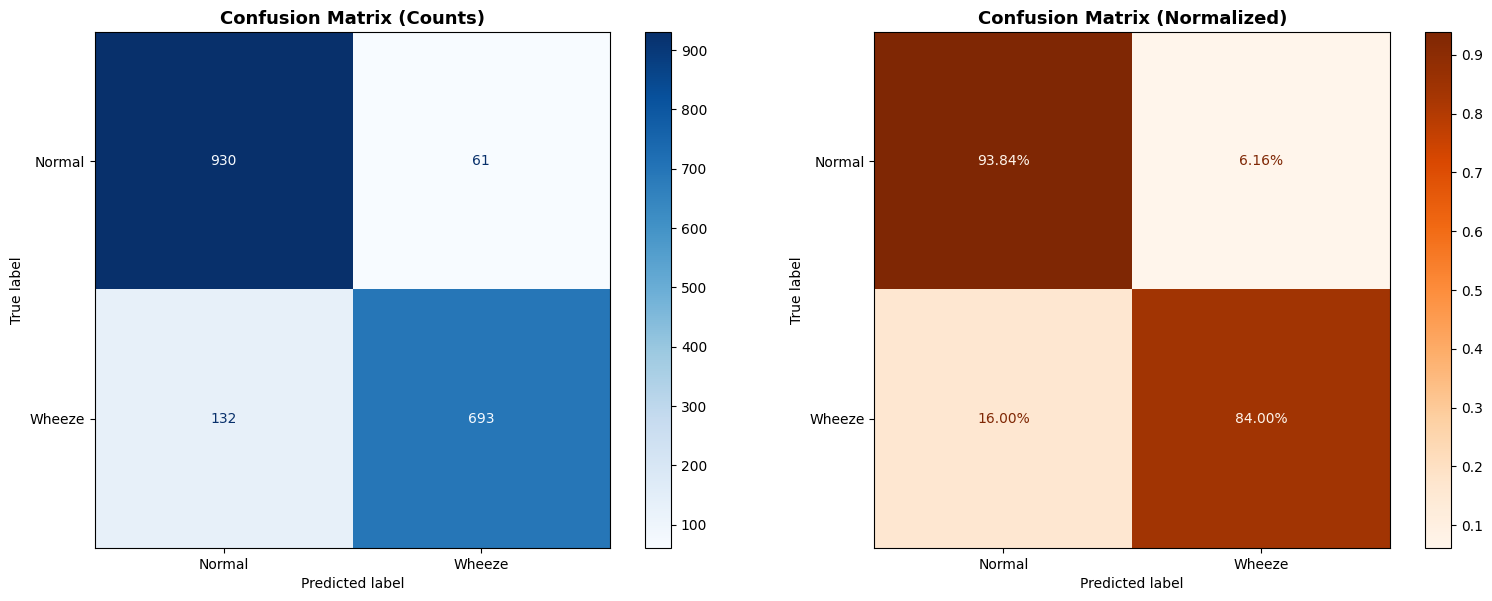


📊 Breakdown:
   True Positives (Wheeze detected correctly):    693
   True Negatives (Normal detected correctly):    930
   False Positives (Normal mistaken as Wheeze):   61  (False alarm)
   False Negatives (Wheeze missed):               132  ⚠️ (Dangerous!)


In [10]:
# ==================== PREDICTIONS ====================
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# ==================== CLASSIFICATION REPORT ====================
print("="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_test, y_pred,
    target_names=['Normal', 'Wheeze'],
    digits=4
))

# ==================== TEST METRICS ====================
loss, acc, prec, rec, auc = model.evaluate(X_test, y_test, verbose=0)

print("="*60)
print("🎯 TEST RESULTS")
print("="*60)
print(f"   Accuracy:    {acc:.4f}  ({acc*100:.1f}%)")
print(f"   Precision:   {prec:.4f}  ({prec*100:.1f}%)")
print(f"   Recall:      {rec:.4f}  ({rec*100:.1f}%)  ⭐ Sensitivity")
print(f"   AUC:         {auc:.4f}")
print(f"   Loss:        {loss:.4f}")

# Grade
if rec >= 0.90:
    grade = "🏆 Excellent!"
elif rec >= 0.85:
    grade = "✅ Very Good"
elif rec >= 0.80:
    grade = "👍 Good"
else:
    grade = "⚠️ Needs improvement - try Transfer Learning or more augmentation"

print(f"\n   Overall: {grade}")

# ==================== CONFUSION MATRIX ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regular CM
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Wheeze']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalized CM
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Normal', 'Wheeze']).plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Explain
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Breakdown:")
print(f"   True Positives (Wheeze detected correctly):    {tp}")
print(f"   True Negatives (Normal detected correctly):    {tn}")
print(f"   False Positives (Normal mistaken as Wheeze):   {fp}  (False alarm)")
print(f"   False Negatives (Wheeze missed):               {fn}  ⚠️ (Dangerous!)")

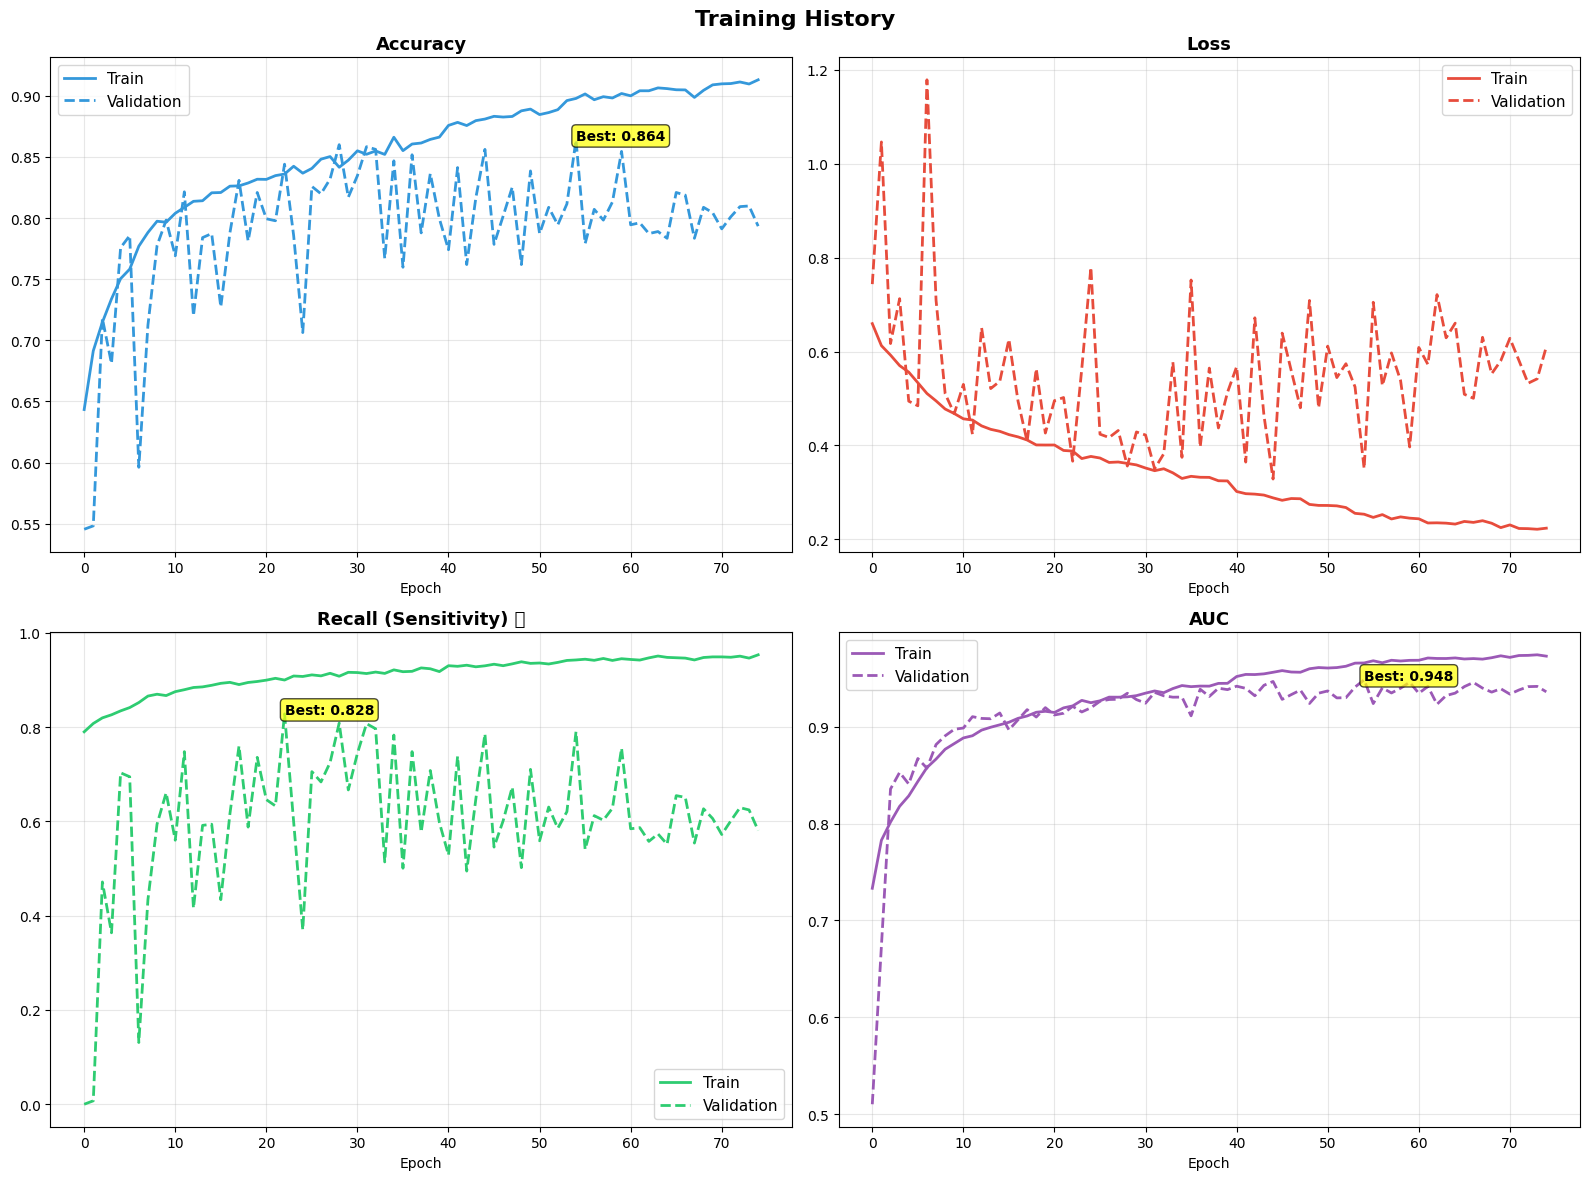

📊 Training history saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('accuracy', 'Accuracy', '#3498db'),
    ('loss', 'Loss', '#e74c3c'),
    ('recall', 'Recall (Sensitivity) ⭐', '#2ecc71'),
    ('auc', 'AUC', '#9b59b6')
]

for ax, (metric, title, color) in zip(axes.flat, metrics):
    ax.plot(history.history[metric], label='Train', color=color, linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Validation',
            color=color, linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Epoch')

    # Add best value annotation
    if metric != 'loss':
        best_val = max(history.history[f'val_{metric}'])
        best_epoch = history.history[f'val_{metric}'].index(best_val)
        ax.annotate(f'Best: {best_val:.3f}',
                   xy=(best_epoch, best_val),
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("📊 Training history saved!")

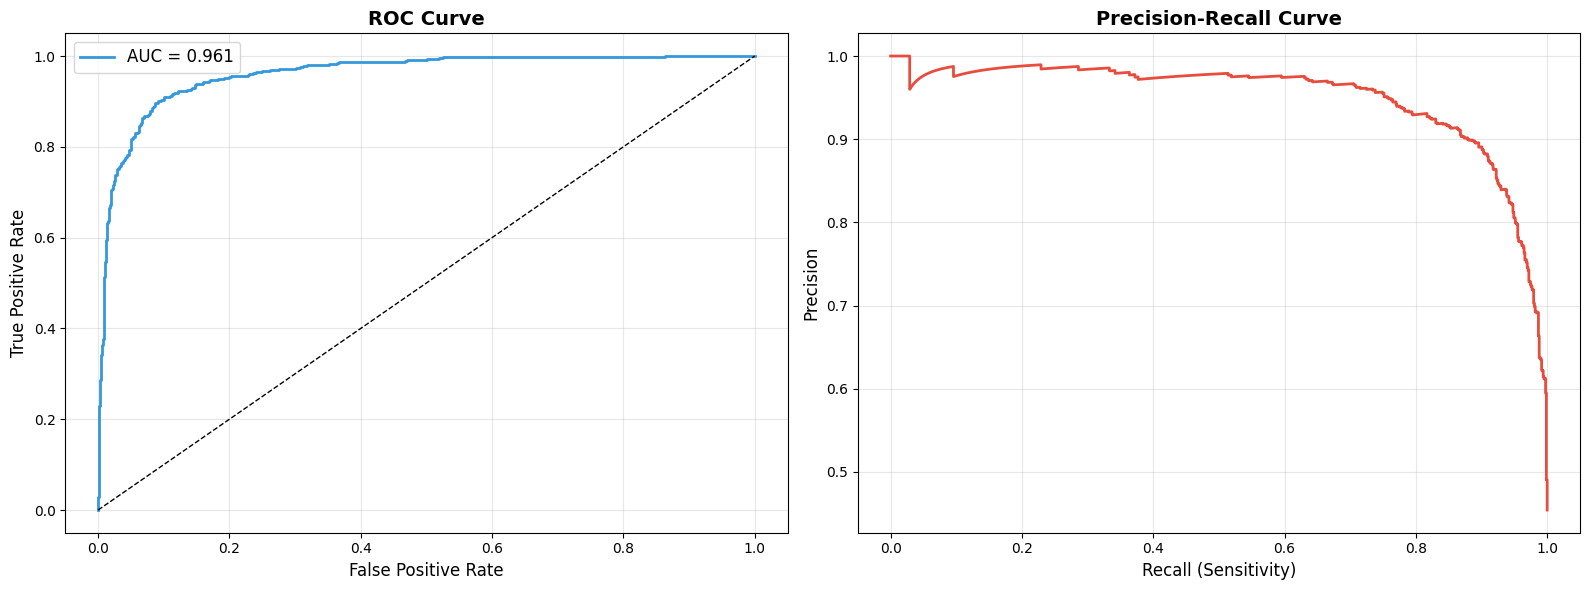


📊 Threshold Analysis:
 Threshold  Precision     Recall         F1   Accuracy
-------------------------------------------------------
      0.30     0.8914     0.8958     0.8936     0.9031 ← best
      0.35     0.8986     0.8812     0.8898     0.9009
      0.40     0.9075     0.8679     0.8872     0.8998
      0.45     0.9135     0.8582     0.8850     0.8987
      0.50     0.9191     0.8400     0.8778     0.8937
      0.55     0.9262     0.8218     0.8709     0.8893
      0.60     0.9298     0.8024     0.8614     0.8827

⭐ Recommended threshold: 0.3
   (Use a lower threshold like 0.3-0.4 if you prioritize catching all wheeze cases)


In [12]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

axes[0].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

axes[1].plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Try different thresholds
print("\n📊 Threshold Analysis:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
print("-" * 55)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_t = (y_pred_prob > threshold).astype(int).flatten()
    tp = np.sum((y_t == 1) & (y_test == 1))
    fp = np.sum((y_t == 1) & (y_test == 0))
    fn = np.sum((y_t == 0) & (y_test == 1))
    tn = np.sum((y_t == 0) & (y_test == 0))

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    a = (tp + tn) / (tp + tn + fp + fn)

    marker = " ← best" if f1 > best_f1 else ""
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

    print(f"{threshold:>10.2f} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {a:>10.4f}{marker}")

print(f"\n⭐ Recommended threshold: {best_threshold}")
print(f"   (Use a lower threshold like 0.3-0.4 if you prioritize catching all wheeze cases)")

In [13]:
print("💾 Exporting model in multiple formats...")
print("="*50)

# 1. Keras format
keras_path = os.path.join(MODEL_PATH, 'wheeze_model.keras')
model.save(keras_path)
size_mb = os.path.getsize(keras_path) / (1024 * 1024)
print(f"✅ Keras:  {keras_path} ({size_mb:.1f} MB)")

# 2. H5 format (for FastAPI server)
h5_path = os.path.join(MODEL_PATH, 'wheeze_model.h5')
model.save(h5_path)
size_mb = os.path.getsize(h5_path) / (1024 * 1024)
print(f"✅ H5:     {h5_path} ({size_mb:.1f} MB)")

# 3. TFLite format (for mobile / ESP32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(MODEL_PATH, 'wheeze_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"✅ TFLite: {tflite_path} ({size_mb:.1f} MB)")

# 4. Save model config & threshold
import json
config = {
    'model_type': 'MobileNetV2' if USE_TRANSFER_LEARNING else 'Custom_CNN',
    'input_shape': list(X.shape[1:]),
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION,
    'n_mels': N_MELS,
    'hop_length': HOP_LENGTH,
    'n_fft': N_FFT,
    'recommended_threshold': best_threshold,
    'test_accuracy': float(acc),
    'test_recall': float(rec),
    'test_precision': float(prec),
    'test_auc': float(auc),
    'classes': {0: 'normal', 1: 'wheeze'}
}

config_path = os.path.join(MODEL_PATH, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config: {config_path}")

print(f"\n📦 All files saved in: {MODEL_PATH}/")
print("\n📁 Files:")
for f in sorted(os.listdir(MODEL_PATH)):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / (1024 * 1024)
    print(f"   {f} ({size:.1f} MB)")

💾 Exporting model in multiple formats...
✅ Keras:  /content/saved_model/wheeze_model.keras (4.9 MB)
✅ H5:     /content/saved_model/wheeze_model.h5 (4.9 MB)
Saved artifact at '/tmp/tmpczte1z1i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 157, 1), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133894094857872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094851920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094852304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094854800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094858256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094850960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094861328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133894094856144: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
# Option 1: Download directly from Colab
from google.colab import files

print("📥 Downloading model files...")
print("   (سيظهر popup للتحميل لكل ملف)\n")

# Download the most important files
for filename in ['wheeze_model.h5', 'wheeze_model.tflite', 'model_config.json']:
    filepath = os.path.join(MODEL_PATH, filename)
    if os.path.exists(filepath):
        print(f"   📄 {filename}")
        files.download(filepath)

# Download training history
history_path = os.path.join(MODEL_PATH, 'training_history.png')
if os.path.exists(history_path):
    files.download(history_path)
    print(f"   📄 training_history.png")

print("\n✅ Download complete!")

In [ ]:
import IPython.display as ipd

def predict_audio_file(wav_path, model, threshold=0.5):
    """
    تجربة النموذج على ملف صوتي
    """
    # Load
    audio, sr = librosa.load(wav_path, sr=SAMPLE_RATE)

    # Take first 5 seconds
    target_length = int(DURATION * sr)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
    else:
        audio = audio[:target_length]

    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_min, mel_max = mel_spec_db.min(), mel_spec_db.max()
    if mel_max - mel_min > 0:
        mel_spec_db = (mel_spec_db - mel_min) / (mel_max - mel_min)
    else:
        mel_spec_db = np.zeros_like(mel_spec_db)

    # Predict
    input_data = mel_spec_db[np.newaxis, ..., np.newaxis]
    pred = model.predict(input_data, verbose=0)[0][0]

    result = 'WHEEZE 🔴' if pred > threshold else 'NORMAL 🟢'
    confidence = pred if pred > 0.5 else 1 - pred

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Waveform
    axes[0].plot(audio, color='#3498db', linewidth=0.5)
    axes[0].set_title('Waveform', fontsize=12)
    axes[0].set_xlabel('Samples')

    # Spectrogram
    axes[1].imshow(mel_spec_db, aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_title('Mel Spectrogram', fontsize=12)
    axes[1].set_xlabel('Time Frames')
    axes[1].set_ylabel('Mel Bands')

    color = '#e74c3c' if pred > threshold else '#2ecc71'
    plt.suptitle(f'Prediction: {result} (Confidence: {confidence:.1%})',
                fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

    # Play audio
    print("🔊 Listen:")
    return ipd.Audio(audio, rate=sr)


# Test with random files
wav_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')]

# Pick one with wheeze and one normal
print("🧪 Testing model on sample files...\n")

test_files = np.random.choice(wav_files, min(3, len(wav_files)), replace=False)
for wav_file in test_files:
    print(f"\n📄 File: {wav_file}")
    wav_path = os.path.join(DATASET_PATH, wav_file)
    audio_widget = predict_audio_file(wav_path, model, threshold=best_threshold)
    display(audio_widget)